<a href="https://colab.research.google.com/github/Bitnut01/misp_py/blob/zadania/zadania/task4_min_power.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pulp

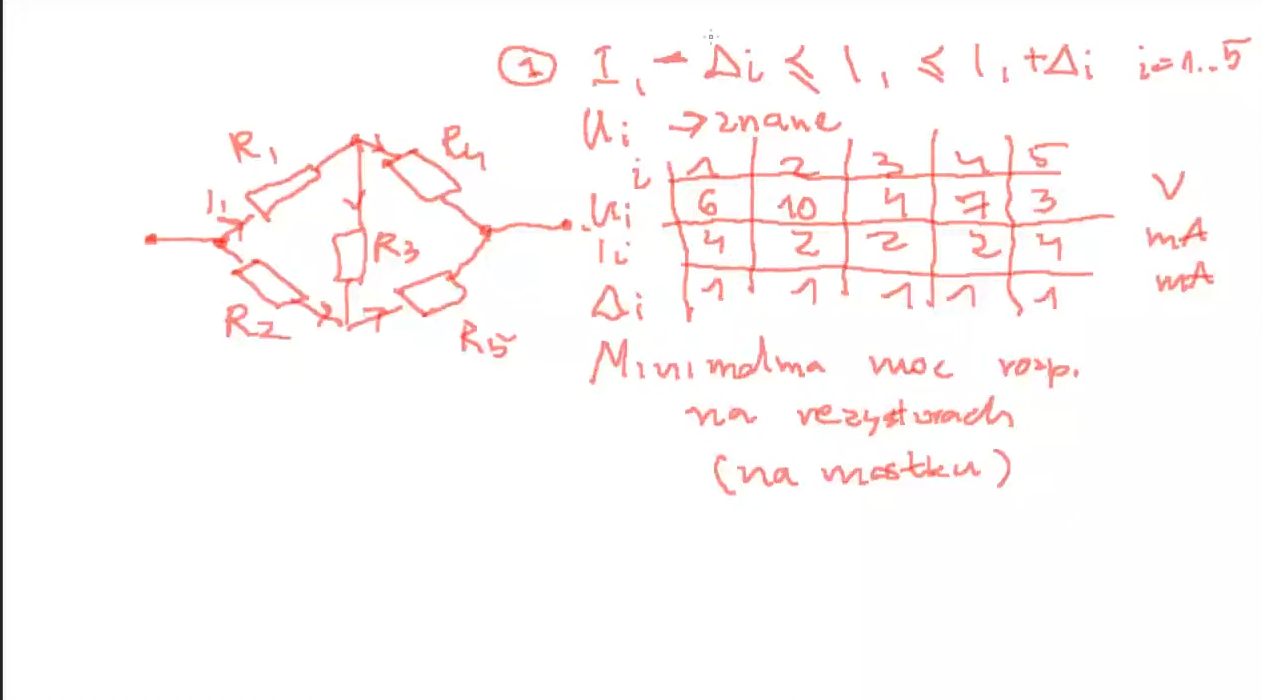

In [6]:
from pulp import LpProblem, LpMinimize, LpVariable, LpStatus, value

In [7]:

U1 = 6
U2 = 10
U3 = 4
U4 = 7
U5 = 3

I_min_1 = 0.003
I_min_2 = 0.001
I_min_3 = 0.001
I_min_4 = 0.001
I_min_5 = 0.003

I_max_1 = 0.005
I_max_2 = 0.003
I_max_3 = 0.003
I_max_4 = 0.003
I_max_5 = 0.005

In [8]:
model = LpProblem("minimum_mocy", LpMinimize)

#Admitancje
G1 = LpVariable('G1', lowBound=0)
G2 = LpVariable('G2', lowBound=0)
G3 = LpVariable('G3', lowBound=0)
G4 = LpVariable('G4', lowBound=0)
G5 = LpVariable('G5', lowBound=0)

model += (U1**2 * G1
          + U2**2 * G2
          + U3**2 * G3
          + U4**2 * G4
          + U5**2 * G5), "Minimalizacja_Mocy"

model += U1 * G1 >= I_min_1, "I1_Min"
model += U1 * G1 <= I_max_1, "I1_Maks"

model += U2 * G2 >= I_min_2, "I2_Min"
model += U2 * G2 <= I_max_2, "I2_Maks"

model += U3 * G3 >= I_min_3, "I3_Min"
model += U3 * G3 <= I_max_3, "I3_Maks"

model += U4 * G4 >= I_min_4, "I4_Min"
model += U4 * G4 <= I_max_4, "I4_Maks"

model += U5 * G5 >= I_min_5, "I5_Min"
model += U5 * G5 <= I_max_5, "I5_Maks"

model += (U1 * G1 + U2 * G2) == (U4 * G4 + U5 * G5), "Rownowaga_Pradu"

model += ((U1 * G1 - U4 * G4 >= I_min_3)
          or (U1 * G1 - U4 * G4 <= -I_min_3)), "Balans_1_Dolna"
model += ((U2 * G2 - U5 * G5 <= I_min_3)
          or (U2 * G2 - U5 * G5 >= -I_min_3)), "Balans_2_Dolna"

model += (U1 * G1 - U4 * G4 <= I_max_3), "gorne_zakresy"
model += (U2 * G2 - U5 * G5 <= I_max_3), "dolne_zakresy"

model.solve()

print("Status:", LpStatus[model.status])
for var in model.variables():
    print(f"{var.name} = {var.varValue}")

print("Minimalna Moc = ", value(model.objective))

Status: Optimal
G1 = 0.0005
G2 = 0.0001
G3 = 0.00025
G4 = 0.00014285714
G5 = 0.001
Minimalna Moc =  0.04799999986
